## Part 4: 100 datasets

### this is where we start to do real science
### part 1 was understanding 1 dataset (and the structure and format of the data ), 
### part2 analyzing a better dataset
### part3 was finding a good preliminary latent space for 40 datasets
### HERE: lets find a GREAT latent space, investigate "others" category, deal with class imbalance by incorporating FullOsc data
### PCA and LDA with various labeling schemes

In [1]:
from utils import *

## data loading 100 files and 15 FullOsc files. takes 3 min 10 sec to run. 
## It turns out 2343 events in the FullOsc 0001-0050 files survive cut 7. 

usually with class imbalance u must *undersample majority class* or add a *weight prop* to 1/n_class. But much better for us is to just load in more signal since that's real data that obviously generalizes the classification/clustering better for the validation set 15 datasets is div by 5 (4:1 split train:val) and gives ~ equally big classes

## load data

In [2]:
trees = {}
for i in range(1, 101):
    idx = f"{i:04d}"
    path = rf"C:\Users\Mathias\Desktop\NEUTRINO CODING\may07_2_cocktail_allhad_{idx}_updated.root"
    f = uproot.open(path)
    trees[idx] = f["MiniBooNE;1"]
#list of strings. e.g. train_keys = ['0001', '0002', ..., '0080']
all_keys = [f"{i:04d}" for i in range(1, 101)]
train_keys = all_keys[:80]
val_keys = all_keys[80:]

#FullOsc files
trees_fullosc = {}
for i in range(1, 31):
    idx = f"{i:04d}"
    path = rf"C:\Users\Mathias\Desktop\NEUTRINO CODING\may07_2_cocktail_allhad_fullosc_{idx}_updated.root"
    f = uproot.open(path)
    trees_fullosc[idx] = f["MiniBooNE;1"]

fullosc_keys = [f"{i:04d}" for i in range(1, 31)]
fullosc_train_keys = fullosc_keys[:24]
fullosc_val_keys = fullosc_keys[24:]

############################################################################################ its only stuff above u change when u get more datasets

#concatenate data from multiple trees
def concatenate_tree_data(trees, keys_to_use):
    
    #dict for vars used 
    var_paths = {
        'thits': "TSplitEventChunk/TSplitEventChunk.data_.THits",
        'vhits': "TSplitEventChunk/TSplitEventChunk.data_.VHits",
        'subevent': "TSplitEventChunk/TSplitEventChunk.data_.Subevent",
        'ot_X': "TOneTrackChunk/TOneTrackChunk.data_.X",
        'ot_Y': "TOneTrackChunk/TOneTrackChunk.data_.Y",
        'ot_Z': "TOneTrackChunk/TOneTrackChunk.data_.Z",
        'ot_UX': "TOneTrackChunk/TOneTrackChunk.data_.UX",
        'ot_UY': "TOneTrackChunk/TOneTrackChunk.data_.UY",
        'ot_UZ': "TOneTrackChunk/TOneTrackChunk.data_.UZ",
        'dist_cer': "TOneTrackChunk/TOneTrackChunk.data_.distToMeanCer",
        'ot_E': "TOneTrackChunk/TOneTrackChunk.data_.E",
        'ot_F': "TOneTrackChunk/TOneTrackChunk.data_.F",
        'twotrack_F': "TTwoTrackChunk/TTwoTrackChunk.data_.F",
        'twotrack_M': "TTwoTrackChunk/TTwoTrackChunk.data_.M",
        'INNO': "TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.INNO",
        'nuance': "TReweightToCVChunk/TReweightToCVChunk.data_.nuanceChannel"
    }
    
    #dict of empty lists. eg data_lists = {'thits': [], 'vhits': [], ...}
    data_lists = {key: [] for key in var_paths}
    
    # this loop gives data_lists with keys as the vars we care for and concatenated entries for all e.g. 80 train datasets
    # take every key in e.g train_keys (['0001', '0002', ..., '0080']), take each of the vars we care about, append to datalists["thits"] etc
    for key in keys_to_use:
        tree = trees[key] # eg tree = trees['0001']
        for var_name, path in var_paths.items():
            data_lists[var_name].append(tree[path].array())
    #also gotta concatenate so its not eg 80 separate entries in data_lists[var_name]. 
    concatenated_data = {}
    for var_name, arrays in data_lists.items():
        concatenated_data[var_name] = ak.concatenate(arrays)
    
    return concatenated_data

############################################################################################## now weve loaded+created concat. function. now structure data 

train_data = concatenate_tree_data(trees, train_keys)
val_data = concatenate_tree_data(trees, val_keys)

fullosc_train_data = concatenate_tree_data(trees_fullosc, fullosc_train_keys)
fullosc_val_data = concatenate_tree_data(trees_fullosc, fullosc_val_keys)


#push out the X matrix (which is -99999 padded) and masks 
def process_combined_data(data):
    
    thits_first = ak.fill_none(ak.firsts(data['thits']), -99999)
    vhits_first = ak.fill_none(ak.firsts(data['vhits']), -99999)
    nsubevents = ak.num(data['subevent'])
    
    ot_X_first = ak.fill_none(ak.firsts(data['ot_X']), -99999)
    ot_Y_first = ak.fill_none(ak.firsts(data['ot_Y']), -99999)
    ot_Z_first = ak.fill_none(ak.firsts(data['ot_Z']), -99999)
    ot_UZ_first = ak.fill_none(ak.firsts(data['ot_UZ']), -99999)
    
    R_el = norm_calculator(ot_X_first, ot_Y_first, ot_Z_first)
    endpoint_R_mu = calc_mu_endpt(data['ot_X'], data['ot_Y'], data['ot_Z'], 
                                  data['ot_UX'], data['ot_UY'], data['ot_UZ'], 
                                  data['dist_cer'])
    
    E_el = ak.fill_none(ak.firsts(data['ot_E']), -99999)
    F_el = ak.fill_none(ak.firsts(data['ot_F']), -99999)
    F_mu = ak.fill_none(ak.pad_none(data['ot_F'], 2)[:, 1], -99999)
    log_Le_Lmu = F_mu - F_el
    
    F_pi0 = ak.fill_none(ak.pad_none(data['twotrack_F'], 2)[:, 1], -99999)
    log_Le_Lpi0 = F_pi0 - F_el
    
    M = ak.fill_none(ak.firsts(data['twotrack_M']), -99999)
    
    thresh_e_mu = 0.01355 + 0.03467*E_el/1000 - 0.008259*E_el**2/10**6
    thresh_e_pi0 = 0.002471 + 0.004115*E_el/1000 - 0.02738*E_el**2/10**6
    thresh_M = 3.203*10**(-2) + 7.417*10**(-3)*E_el/1000 + E_el**2/10**6

    
    mask0 = (empty_mask(data['thits']) & 
             empty_mask(data['subevent']) & 
             empty_mask(data['ot_X']) & 
             empty_mask_second(data['dist_cer']) & 
             empty_mask_second(data['ot_X']) & 
             empty_mask_second(data['ot_UX']) &
             empty_mask(data['ot_E']) & 
             empty_mask_second(data['ot_F']) & 
             empty_mask_second(data['twotrack_F']) & 

             empty_mask(data['twotrack_M']))
    
    mask1 = mask0 & (thits_first > 200)
    mask2 = mask1 & (vhits_first < 6)
    mask3 = mask2 & (nsubevents == 1)
    mask4 = mask3 & (R_el < 500)
    mask5 = mask4 & (endpoint_R_mu < 488)
    mask6 = mask5 & (E_el > 475) & (E_el < 3000) 
    mask7 = mask6 & (log_Le_Lmu > thresh_e_mu)
    mask8 = mask7 & (log_Le_Lpi0 > thresh_e_pi0)
    mask9 = mask8 & (M/1000 < thresh_M)
    
    INNO_first = ak.firsts(data['INNO'])
    nuance_first = ak.firsts(data['nuance'])
    
    CCQE_mu_mask = ((INNO_first == 1) | (INNO_first == 2)) & (nuance_first == 1)
    CCQE_e_mask = ((INNO_first == 3) | (INNO_first == 4)) & (nuance_first == 1)
    NC_pi0_mask = (nuance_first == 6) | (nuance_first == 8) | (nuance_first == 96)
    rest_mask = ~(CCQE_mu_mask | CCQE_e_mask | NC_pi0_mask)
    
    X = np.column_stack([ #this just takes the columns and stacks em. so now evnt 0 has its info in first entry etc. so easy to mask
        thits_first, vhits_first, nsubevents, R_el, 
        endpoint_R_mu, E_el, log_Le_Lmu, log_Le_Lpi0, M, ot_UZ_first  
    ])
    
    return X, mask7, mask8, mask9, CCQE_mu_mask, CCQE_e_mask, NC_pi0_mask, rest_mask

#here's all that data for our 4 datasets (normal+fullosc)x(train+val)
X_train, mask7_train, mask8_train, mask9_train, CCQE_mu_train, CCQE_e_train, NC_pi0_train, rest_train = process_combined_data(train_data)
X_val, mask7_val, mask8_val, mask9_val, CCQE_mu_val, CCQE_e_val, NC_pi0_val, rest_val = process_combined_data(val_data)
X_fullosc_train, mask7_fullosc_train, mask8_fullosc_train, mask9_fullosc_train, CCQE_mu_fullosc_train, CCQE_e_fullosc_train, NC_pi0_fullosc_train, rest_fullosc_train = process_combined_data(fullosc_train_data)
X_fullosc_val, mask7_fullosc_val, mask8_fullosc_val, mask9_fullosc_val, CCQE_mu_fullosc_val, CCQE_e_fullosc_val, NC_pi0_fullosc_val, rest_fullosc_val = process_combined_data(fullosc_val_data)

#we make this to easily access the masks and data for each mask number (different lengths for train vs val, different values for each mask and train vs val)
masks_dict = {
    '7': (mask7_train, mask7_val, mask7_fullosc_train, mask7_fullosc_val),
    '8': (mask8_train, mask8_val, mask8_fullosc_train, mask8_fullosc_val),
    '9': (mask9_train, mask9_val, mask9_fullosc_train, mask9_fullosc_val) }

datasets = {}

for mask_num, (mask_train, mask_val, mask_fullosc_train, mask_fullosc_val) in masks_dict.items():
    
    #w/out fullosc
    X_train_masked = X_train[mask_train]
    X_val_masked = X_val[mask_val]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_masked)
    X_val_scaled = scaler.transform(X_val_masked)
    datasets[f'mask{mask_num}'] = { #eg 'mask7': { X_train_scaled: ..., X_val_scaled: ..., ccqe masks etc }, 
        'X_train_scaled': X_train_scaled,
        'X_val_scaled': X_val_scaled,
        'CCQE_mu_train': CCQE_mu_train[mask_train],
        'CCQE_e_train': CCQE_e_train[mask_train],
        'NC_pi0_train': NC_pi0_train[mask_train],
        'rest_train': rest_train[mask_train],
        'CCQE_mu_val': CCQE_mu_val[mask_val],
        'CCQE_e_val': CCQE_e_val[mask_val],
        'NC_pi0_val': NC_pi0_val[mask_val],
        'rest_val': rest_val[mask_val],
        'scaler': scaler
    }
    
    #with FullOsc. note np.vstack concatenates lists eg np.vstack([1,2],[3,4]) = [[1,2],[3,4]]
    X_train_combined = np.vstack([X_train[mask_train], X_fullosc_train[mask_fullosc_train]])
    X_val_combined = np.vstack([X_val[mask_val], X_fullosc_val[mask_fullosc_val]])
    
    CCQE_mu_train_combined = np.concatenate([CCQE_mu_train[mask_train], CCQE_mu_fullosc_train[mask_fullosc_train]])
    CCQE_e_train_combined = np.concatenate([CCQE_e_train[mask_train], CCQE_e_fullosc_train[mask_fullosc_train]])
    NC_pi0_train_combined = np.concatenate([NC_pi0_train[mask_train], NC_pi0_fullosc_train[mask_fullosc_train]])
    rest_train_combined = np.concatenate([rest_train[mask_train], rest_fullosc_train[mask_fullosc_train]])
    
    CCQE_mu_val_combined = np.concatenate([CCQE_mu_val[mask_val], CCQE_mu_fullosc_val[mask_fullosc_val]])
    CCQE_e_val_combined = np.concatenate([CCQE_e_val[mask_val], CCQE_e_fullosc_val[mask_fullosc_val]])
    NC_pi0_val_combined = np.concatenate([NC_pi0_val[mask_val], NC_pi0_fullosc_val[mask_fullosc_val]])
    rest_val_combined = np.concatenate([rest_val[mask_val], rest_fullosc_val[mask_fullosc_val]])
    
    scaler_combined = StandardScaler()
    X_train_scaled_combined = scaler_combined.fit_transform(X_train_combined)
    X_val_scaled_combined = scaler_combined.transform(X_val_combined)
    
    datasets[f'mask{mask_num}_fullOsc'] = {
        'X_train_scaled': X_train_scaled_combined,
        'X_val_scaled': X_val_scaled_combined,
        'CCQE_mu_train': CCQE_mu_train_combined, #note that these are literally masks [True False etc]
        'CCQE_e_train': CCQE_e_train_combined,
        'NC_pi0_train': NC_pi0_train_combined,
        'rest_train': rest_train_combined,
        'CCQE_mu_val': CCQE_mu_val_combined,
        'CCQE_e_val': CCQE_e_val_combined,
        'NC_pi0_val': NC_pi0_val_combined,
        'rest_val': rest_val_combined,
        'scaler': scaler_combined} #can prolly remove this honestly
    
    # output: "datasets". which is a dict of dicts
    # this dict has keys like 'mask7', 'mask8', 'mask9', 'mask7_fullOsc', etc.
    # each of these keys has a dict with the keys and values shown just above

## LDA of 3 categories ("others" glued on after fit transform)

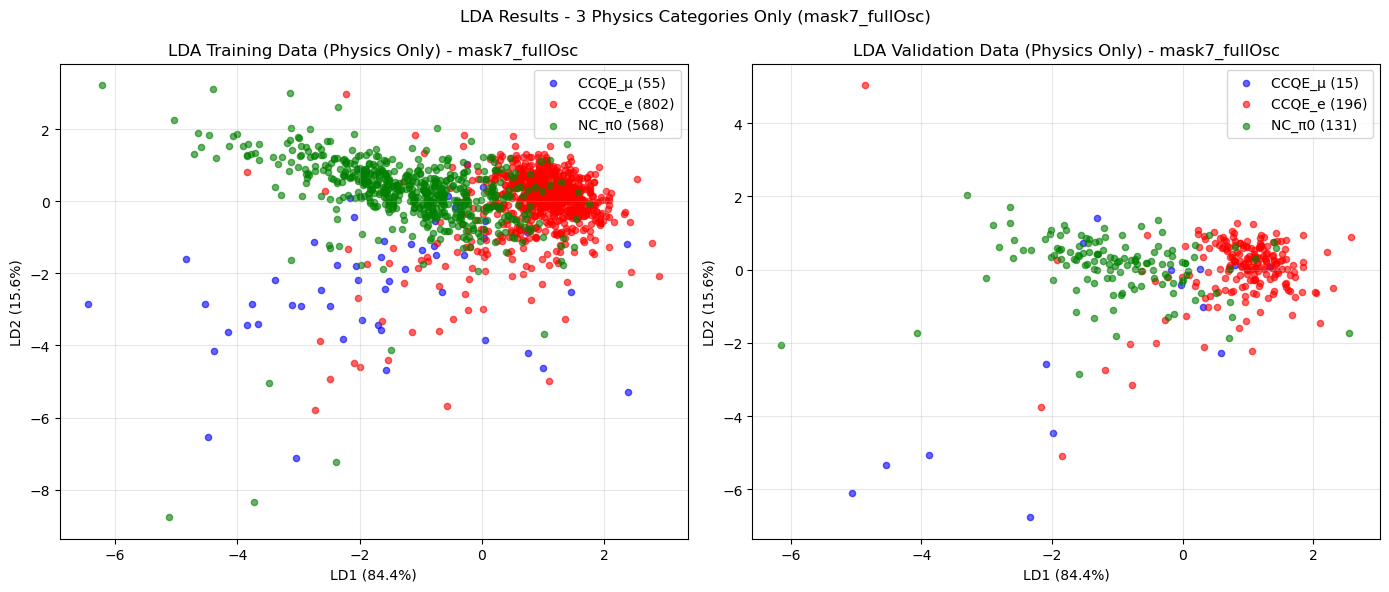

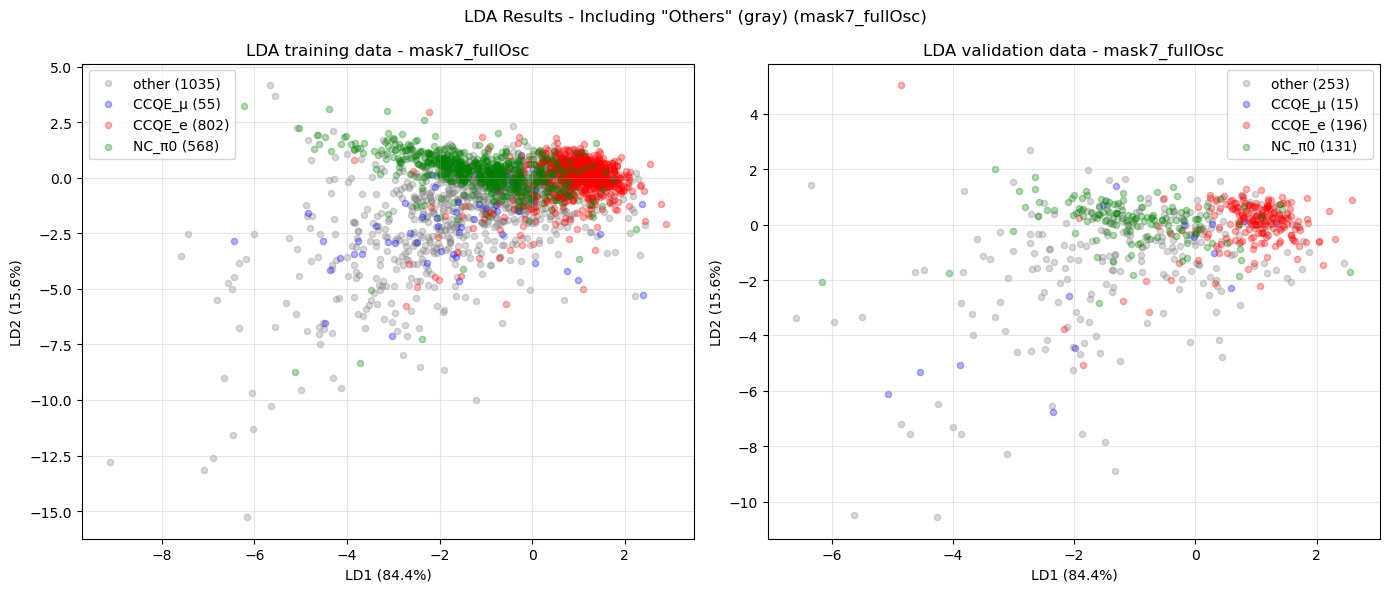

In [3]:
# U CAN SELECT WHICH DATASET TO ANALYZE!
# options: 'mask7', 'mask7_fullOsc', 'mask8', 'mask8_fullOsc', 'mask9', 'mask9_fullOsc'
DATASET_NAME = 'mask7_fullOsc'  #CHANGE THIS TO ANALYZE DIFFERENT CUTS/COMBINATIONS
########################################################################################################################################

dataset = datasets[DATASET_NAME]
X_train_scaled = dataset['X_train_scaled']
X_val_scaled = dataset['X_val_scaled']
CCQE_mu_train = dataset['CCQE_mu_train']
CCQE_e_train = dataset['CCQE_e_train']
NC_pi0_train = dataset['NC_pi0_train']
rest_train = dataset['rest_train']
CCQE_mu_val = dataset['CCQE_mu_val']
CCQE_e_val = dataset['CCQE_e_val']
NC_pi0_val = dataset['NC_pi0_val']
rest_val = dataset['rest_val']

# give each category its own integer, pca wants only 1 input label array
def create_labels(CCQE_mu_mask, CCQE_e_mask, NC_pi0_mask):
    labels = np.full(len(CCQE_mu_mask), 3)  # Start with 3 (other)
    labels[CCQE_mu_mask] = 0
    labels[CCQE_e_mask] = 1  
    labels[NC_pi0_mask] = 2
    return labels

#create labels for training and validation
y_train_all = create_labels(CCQE_mu_train, CCQE_e_train, NC_pi0_train)
y_val_all = create_labels(CCQE_mu_val, CCQE_e_val, NC_pi0_val)

#same as in part 3, see my comments there
physics_mask_train = y_train_all != 3
physics_mask_val = y_val_all != 3

X_train_physics = X_train_scaled[physics_mask_train]
y_train_physics = y_train_all[physics_mask_train]

lda = LinearDiscriminantAnalysis(n_components=2) 
lda.fit(X_train_physics, y_train_physics)

X_train_lda = lda.transform(X_train_scaled)
X_val_lda = lda.transform(X_val_scaled)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'gray'}
labels_dict = {0: 'CCQE_μ', 1: 'CCQE_e', 2: 'NC_π0', 3: 'other'}

for label in [0, 1, 2]:  
    mask = (y_train_all == label)
    if sum(mask) > 0:
        ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6, s=20)

ax1.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'LDA Training Data (Physics Only) - {DATASET_NAME}')
ax1.legend()
ax1.grid(True, alpha=0.3)

for label in [0, 1, 2]:  
    mask = (y_val_all == label)
    if sum(mask) > 0:
        ax2.scatter(X_val_lda[mask, 0], X_val_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.6, s=20)

ax2.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax2.set_title(f'LDA Validation Data (Physics Only) - {DATASET_NAME}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'LDA Results - 3 Physics Categories Only ({DATASET_NAME})')
plt.tight_layout()
plt.show()

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for label in [3, 0,1, 2]:
    mask = y_train_all == label
    if sum(mask) > 0:
        ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})', alpha=0.3, s=20)

ax1.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'LDA training data - {DATASET_NAME}')
ax1.legend()
ax1.grid(True, alpha=0.3)

for label in [3, 0,1, 2]:
    mask = y_val_all == label
    if sum(mask) > 0:
        ax2.scatter(X_val_lda[mask, 0], X_val_lda[mask, 1], 
                   c=colors[label], label=f'{labels_dict[label]} ({sum(mask)})',
                   alpha=0.3, s=20 )

ax2.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax2.set_title(f'LDA validation data - {DATASET_NAME}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'LDA Results - Including "Others" (gray) ({DATASET_NAME})')
plt.tight_layout()
plt.show()

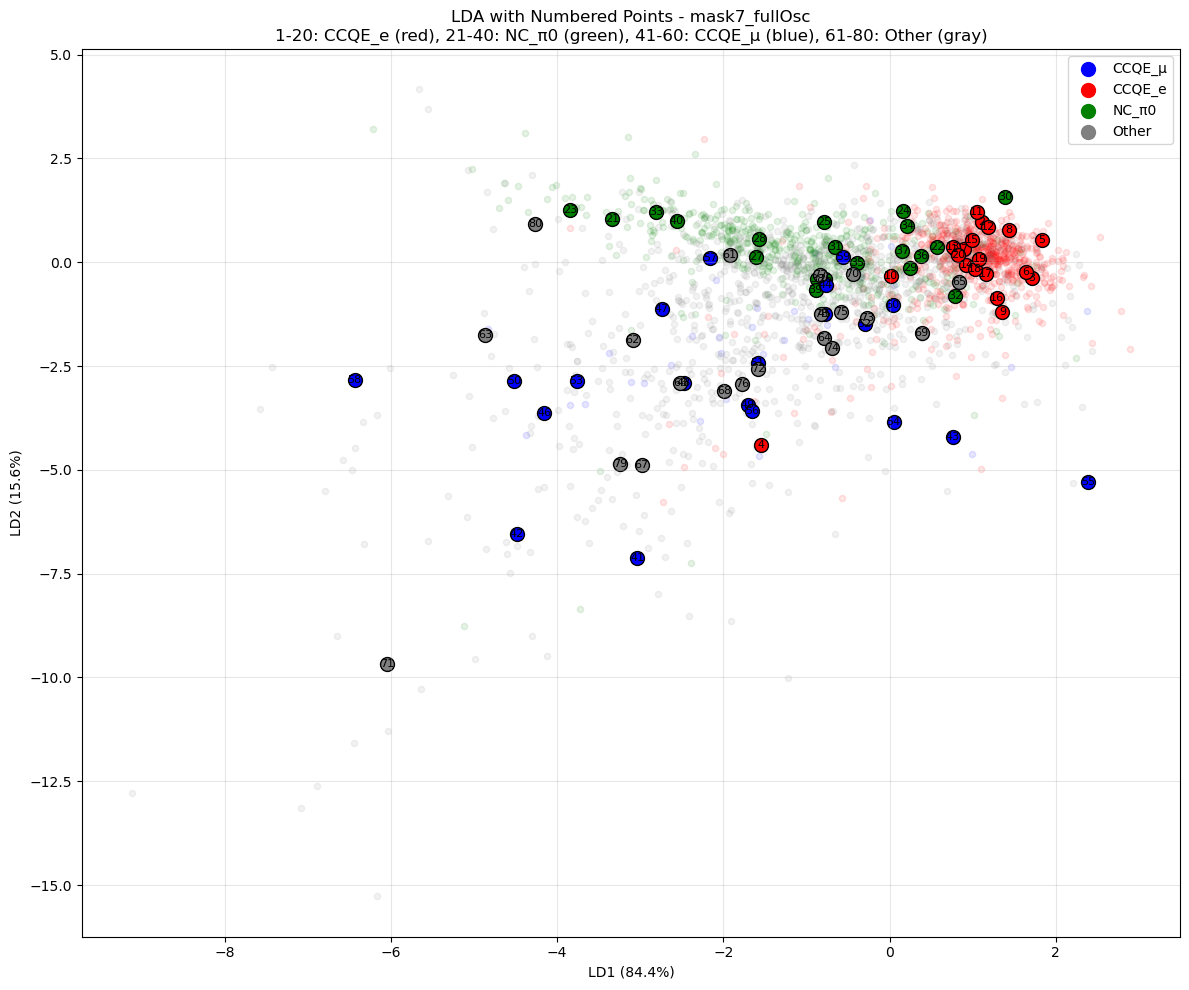


FEATURE VALUES FOR SELECTED POINTS - mask7_fullOsc
  # |    Class |     LD1 |     LD2 | INNO | nuance |       thits |       vhits |  nsubevents |        R_el | endpoint_R_mu |        E_el |  log_Le_Lmu | log_Le_Lpi0 |           M |       ot_UZ | 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  1 |   CCQE_e |   0.784 |   0.315 |    3 |      1 |     628.000 |       0.000 |       1.000 |     462.000 |     440.660 |     605.675 |       0.067 |      -0.004 |      10.930 |       0.667 | 
  2 |   CCQE_e |   1.108 |   0.977 |    3 |      1 |     953.000 |       1.000 |       1.000 |     359.705 |     288.624 |     918.898 |       0.222 |      -0.005 |      23.044 |       0.905 | 
  3 |   CCQE_e |   1.709 |  -0.370 |    3 |      1 |     661.000 |       0.000 |       1.000 |     421.714 |     374.431 |     511.582 |       0.101 |       0.002 |      23.252 |     

In [4]:
np.random.seed(42) 
n_points_per_class = 20
selected_indices = []


for label in [1, 2, 0, 3]:  # smae here. see part3
    class_indices = np.where(y_train_all == label)[0]
    selected = np.random.choice(class_indices, n_points_per_class, replace=False)
    selected_indices.extend(selected)

n_regular_masked = np.sum(mask7_train) 

INNO_selected = []
nuance_selected = []
original_features = []

for idx in selected_indices:
    if idx < n_regular_masked:
        original_idx = np.where(mask7_train)[0][idx]
        INNO_selected.append(int(ak.firsts(train_data['INNO'])[original_idx]))
        nuance_selected.append(int(ak.firsts(train_data['nuance'])[original_idx]))
        original_features.append(X_train[original_idx])
    else:
        fullosc_idx = idx - n_regular_masked
        original_idx = np.where(mask7_fullosc_train)[0][fullosc_idx]
        INNO_selected.append(int(ak.firsts(fullosc_train_data['INNO'])[original_idx]))
        nuance_selected.append(int(ak.firsts(fullosc_train_data['nuance'])[original_idx]))
        original_features.append(X_fullosc_train[original_idx])

fig, ax = plt.subplots(figsize=(12, 10))

for label in [0, 1, 2, 3]:
    mask = y_train_all == label
    if sum(mask) > 0:
        ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
                   c=colors[label], alpha=0.1, s=20)

for i, idx in enumerate(selected_indices):
    point_number = i + 1
    ax.scatter(X_train_lda[idx, 0], X_train_lda[idx, 1], 
               c=colors[y_train_all[idx]], s=100, edgecolors='black', linewidth=1)
    ax.annotate(str(point_number), (X_train_lda[idx, 0], X_train_lda[idx, 1]), 
                fontsize=8, ha='center', va='center')

ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'LDA with Numbered Points - {DATASET_NAME}\n1-20: CCQE_e (red), 21-40: NC_π0 (green), 41-60: CCQE_μ (blue), 61-80: Other (gray)')
ax.grid(True, alpha=0.3)
ax.legend([plt.scatter([], [], c=colors[i], s=100) for i in range(4)], 
          ['CCQE_μ', 'CCQE_e', 'NC_π0', 'Other'])
plt.tight_layout()
plt.show()

# here i just wanted to print  values for some selected points
print("\n" + "="*120)
print(f"FEATURE VALUES FOR SELECTED POINTS - {DATASET_NAME}")
print("="*120)

feature_names = ['thits', 'vhits', 'nsubevents', 'R_el', 'endpoint_R_mu', 
                 'E_el', 'log_Le_Lmu', 'log_Le_Lpi0', 'M', 'ot_UZ']

#header
print(f"{'#':>3} | {'Class':>8} | {'LD1':>7} | {'LD2':>7} | {'INNO':>4} | {'nuance':>6} | ", end="")
for feat in feature_names:
    print(f"{feat:>11} | ", end="")
print()
print("-" * 180)

#data
for i, idx in enumerate(selected_indices):
    point_num = i + 1
    class_name = labels_dict[y_train_all[idx]]
    
    print(f"{point_num:3d} | {class_name:>8} | {X_train_lda[idx, 0]:7.3f} | {X_train_lda[idx, 1]:7.3f} | ", end="")
    print(f"{INNO_selected[i]:4d} | {nuance_selected[i]:6d} | ", end="")
    
    # Print original feature values
    for j, val in enumerate(original_features[i]):
        if val == -99999:
            print(f"{'N/A':>11} | ", end="")
        else:
            print(f"{val:11.3f} | ", end="")
    print()
    
    if point_num in [20, 40, 60]:
        print("-" * 180)

## let's see if we get something additional out of looking at Nuance Channels 
(i dont think so, the 4-category already captures Nuance==1, which is the only clear cluster here)

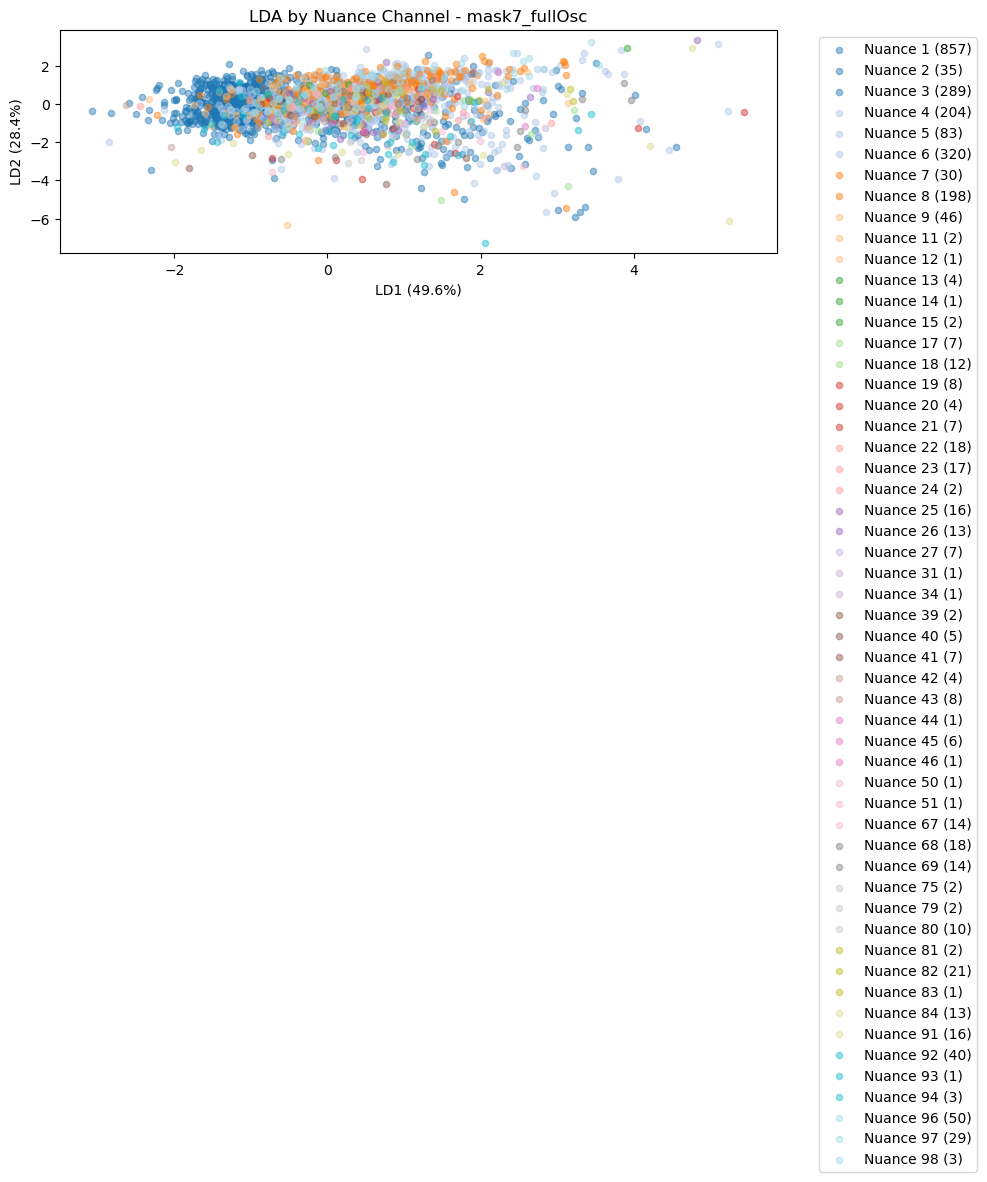

In [5]:
nuance_train = ak.firsts(train_data['nuance'])[mask7_train]
nuance_fullosc_train = ak.firsts(fullosc_train_data['nuance'])[mask7_fullosc_train]
nuance_labels = np.concatenate([nuance_train, nuance_fullosc_train])

lda_nuance = LinearDiscriminantAnalysis()
X_train_lda_nuance = lda_nuance.fit_transform(X_train_scaled, nuance_labels)

plt.figure(figsize=(10, 8))
unique_nuances = np.unique(nuance_labels)
colors_nuance = plt.cm.tab20(np.linspace(0, 1, len(unique_nuances)))

for i, nuance in enumerate(unique_nuances):
    mask = nuance_labels == nuance
    plt.scatter(X_train_lda_nuance[mask, 0], X_train_lda_nuance[mask, 1], 
                c=[colors_nuance[i]], label=f'Nuance {int(nuance)} ({sum(mask)})',
                alpha=0.45, s=20)

plt.xlabel(f'LD1 ({lda_nuance.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'LD2 ({lda_nuance.explained_variance_ratio_[1]:.1%})')
plt.title('LDA by Nuance Channel - mask7_fullOsc')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## find out why code that was so nice on may dataset is terrible on this...

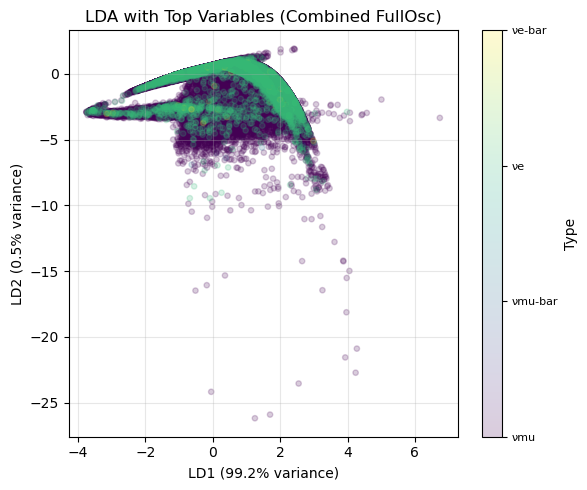

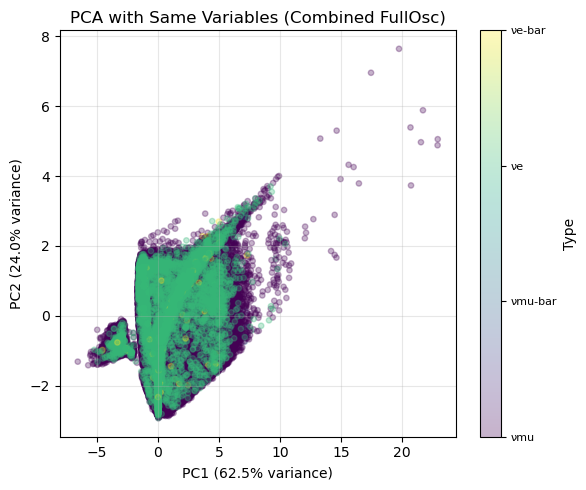

In [6]:
combined_ot_E = ak.concatenate([train_data['ot_E'], fullosc_train_data['ot_E']])
combined_INNO = ak.concatenate([train_data['INNO'], fullosc_train_data['INNO']])

mask = (ak.num(combined_ot_E) > 1)
el_E = np.array(ak.fill_none(ak.firsts(combined_ot_E[mask]), 0))
mu_E = np.array(ak.fill_none(ak.pad_none(combined_ot_E[mask], 2)[:, 1], 0))
total_E = el_E + mu_E

data_matrix = np.column_stack([
    np.log(el_E),
    np.log(mu_E),
    np.divide(el_E, total_E, out=np.zeros_like(el_E), where=total_E!=0),
    np.divide(mu_E, total_E, out=np.zeros_like(mu_E), where=total_E!=0),
    np.divide(el_E - mu_E, total_E + 1e-6, out=np.zeros_like(el_E), where=total_E>0),
    mu_E
])

neutrino_types = np.array(ak.firsts(combined_INNO[mask]))

scaler = RobustScaler()
data_scaled = scaler.fit_transform(data_matrix)

lda = LinearDiscriminantAnalysis(n_components=3)
lda_result = lda.fit_transform(data_scaled, neutrino_types)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(lda_result[:, 0], lda_result[:, 1], 
                     c=neutrino_types, cmap='viridis', alpha=0.2, s=15)
cbar = plt.colorbar(scatter, label='Type', ticks=[1, 2, 3, 4])
cbar.ax.set_yticklabels(['νmu', 'νmu-bar', 'νe', 'νe-bar'], fontsize=8)
plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('LDA with Top Variables (Combined FullOsc)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pca = PCA()
pca_result = pca.fit_transform(data_scaled)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                     c=neutrino_types, cmap='viridis', alpha=0.3, s=15)
cbar = plt.colorbar(scatter, label='Type', ticks=[1, 2, 3, 4])
cbar.ax.set_yticklabels(['νmu', 'νmu-bar', 'νe', 'νe-bar'], fontsize=8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA with Same Variables (Combined FullOsc)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PCA of the "others" category. trying to make sense of it

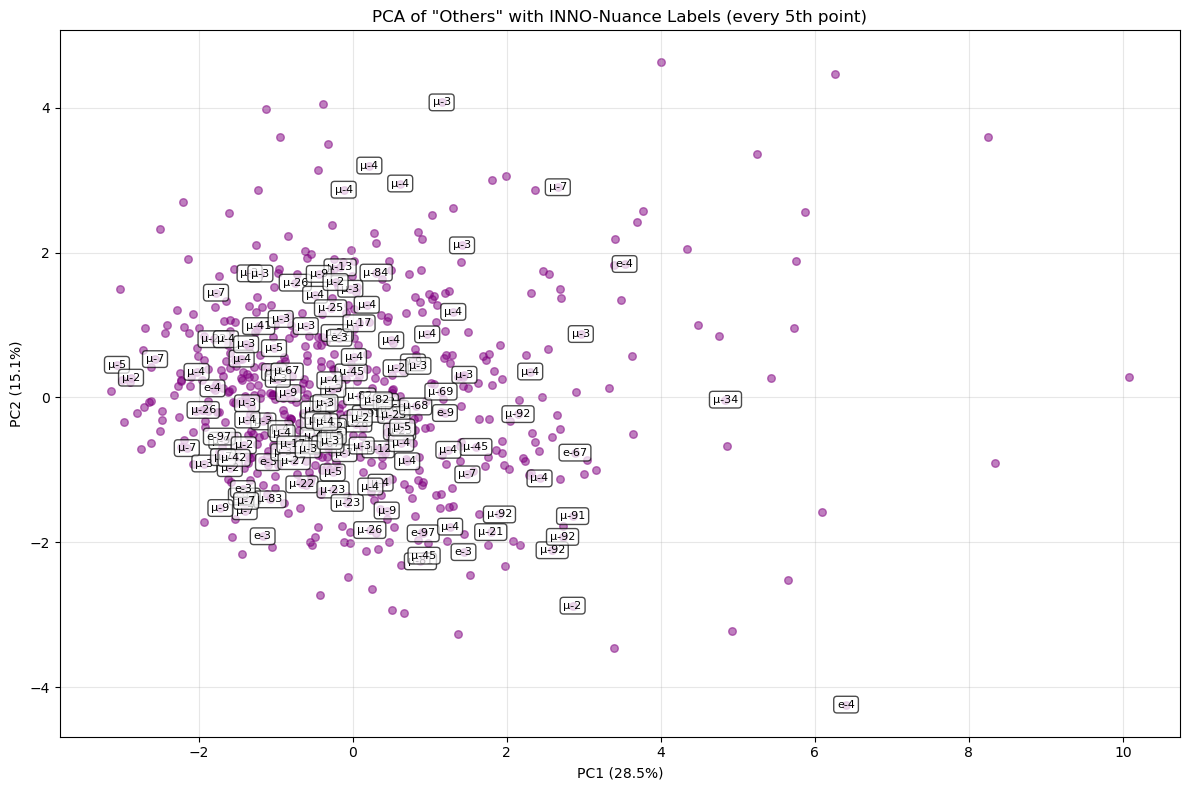

In [7]:
#reloading the data in case we want to check for something else than mask7 (eg mask7_fullOsc)
dataset = datasets['mask7']
X_train_scaled = dataset['X_train_scaled']

#by y i mean labels. its a label array for the training data
y_train = create_labels(dataset['CCQE_mu_train'], dataset['CCQE_e_train'], dataset['NC_pi0_train'])
others_mask = y_train == 3

X_others = X_train_scaled[others_mask]

#we're doing pca but we're tracking the nuance. (btw almost all are INNO 1 and 2)
nuance_all = ak.firsts(train_data['nuance'])[mask7_train]
nuance_others = np.array(nuance_all[others_mask])

inno_all = ak.firsts(train_data['INNO'])[mask7_train]
inno_others = np.array(inno_all[others_mask])

pca = PCA(n_components=2)
X_others_pca = pca.fit_transform(X_others)

plt.figure(figsize=(12, 8))
plt.scatter(X_others_pca[:, 0], X_others_pca[:, 1], c='purple', alpha=0.5, s=30)

#show the inno and nuance
for i in range(0, len(X_others_pca), 5):
    if inno_others[i] in [1, 2]:
        particle = 'μ'
    elif inno_others[i] in [3, 4]:
        particle = 'e'
    label_text = f"{particle}-{int(nuance_others[i])}"
    
    plt.text(X_others_pca[i, 0], X_others_pca[i, 1], label_text, 
             fontsize=8, ha='center', va='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'PCA of "Others" with INNO-Nuance Labels (every 5th point)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()